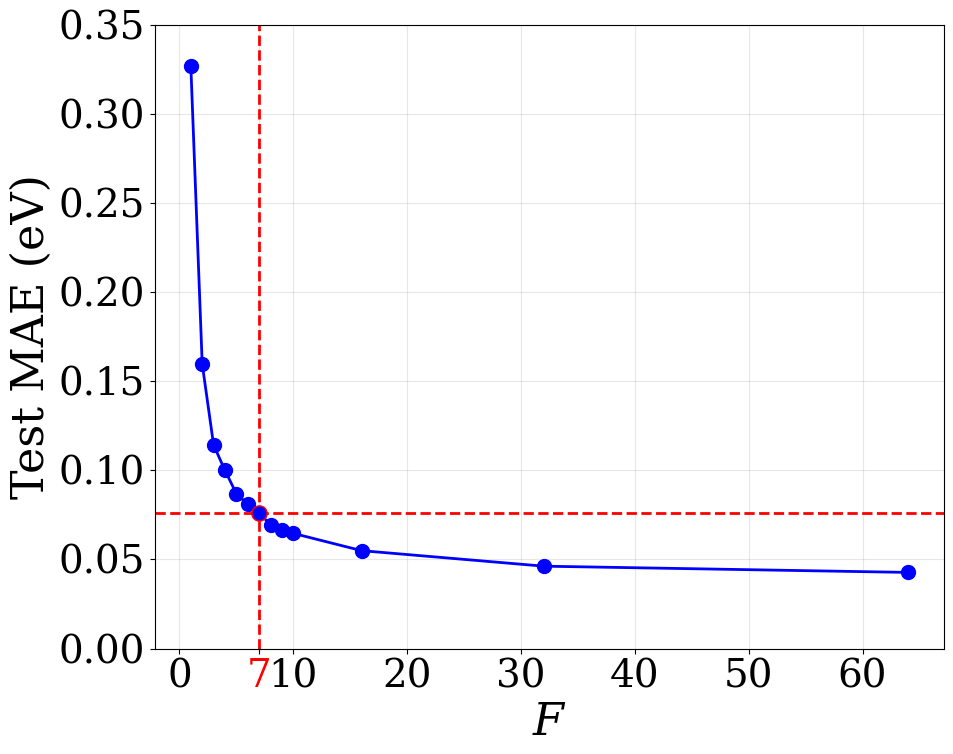

In [1]:
# Get substitutional energies of materials

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator

# Set global publication-quality settings
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 22
mpl.rcParams['axes.labelsize'] = 26
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20

# Data
F = [1,2,3,4,5,6,7,8,9,10,16,32,64]
MAE=[0.327,0.1597,0.1142,0.0999,0.0869,0.0809,0.0761,0.0694,0.0666,0.0646,0.0549,0.0462,0.0427]

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(F, MAE, marker='o', linestyle='-', color='b', markersize=10, linewidth=2)

f_target = 7
i = F.index(f_target)            # find the index of K=7
y_target = MAE[i]                # its MAE

# full-span guides
ax.axvline(f_target, color='red', linestyle='--', linewidth=2)
ax.axhline(y_target, color='red', linestyle='--', linewidth=2)

# ensure 7 is a major tick
ticks = np.unique(np.r_[ax.get_xticks(), f_target])
ax.xaxis.set_major_locator(FixedLocator(ticks))

# optional: make the "7" label stand out
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    if np.isclose(tick, f_target):
        label.set_color('red')

# highlight the intersection
ax.scatter([f_target], [y_target], s=120, facecolor='b', edgecolor='red', zorder=5)

# Label axes and add grid
ax.set_xlabel(r'$F$', fontsize=32)
ax.set_ylabel(r'Test MAE (eV)', fontsize=32)
ax.set_ylim(0.0, 0.35)
ax.grid(alpha=0.3)

# Set tick parameters for better visibility
ax.tick_params(axis='both', which='major', labelsize=28)
plt.savefig('F-convergence.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Fitted parameters for f(x) = c + b*x^{-alpha}:
c     = 0.045958 ± 0.002376
b     = 0.279172 ± 0.004194
alpha = 1.223078 ± 0.042101
R^2   = 0.997784


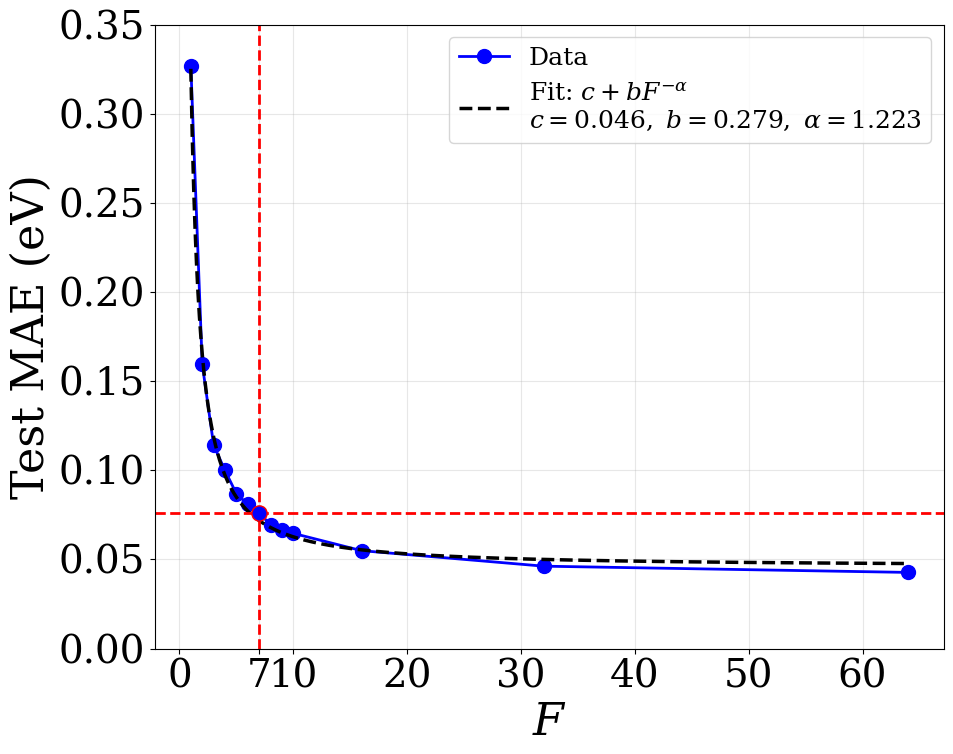

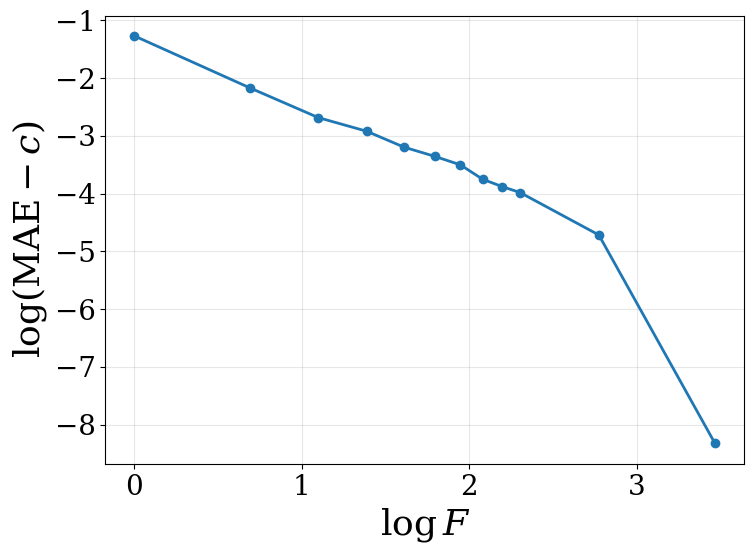

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
from scipy.optimize import curve_fit

# Set global publication-quality settings
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 22
mpl.rcParams['axes.labelsize'] = 26
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20

# Data
F = np.array([1,2,3,4,5,6,7,8,9,10,16,32,64], dtype=float)
MAE = np.array([0.327,0.1597,0.1142,0.0999,0.0869,0.0809,0.0761,
                0.0694,0.0666,0.0646,0.0549,0.0462,0.0427], dtype=float)

# Power-law-with-floor model: f(x) = c + b * x^{-alpha}
def power_law_floor(x, c, b, alpha):
    return c + b * x**(-alpha)

# Initial guess
# c: asymptotic floor
# b: amplitude
# alpha: decay exponent
p0 = [0.04, 0.28, 1.0]

# Bounds to keep parameters sensible
bounds = ([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf])

# Fit
params, cov = curve_fit(
    power_law_floor,
    F,
    MAE,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
c_fit, b_fit, alpha_fit = params

# Standard errors
errs = np.sqrt(np.diag(cov))
c_err, b_err, alpha_err = errs

# Predictions
MAE_fit = power_law_floor(F, c_fit, b_fit, alpha_fit)
F_dense = np.linspace(F.min(), F.max(), 500)
MAE_dense = power_law_floor(F_dense, c_fit, b_fit, alpha_fit)

# R^2
ss_res = np.sum((MAE - MAE_fit)**2)
ss_tot = np.sum((MAE - np.mean(MAE))**2)
r2 = 1 - ss_res / ss_tot

print("Fitted parameters for f(x) = c + b*x^{-alpha}:")
print(f"c     = {c_fit:.6f} ± {c_err:.6f}")
print(f"b     = {b_fit:.6f} ± {b_err:.6f}")
print(f"alpha = {alpha_fit:.6f} ± {alpha_err:.6f}")
print(f"R^2   = {r2:.6f}")

# Optional: check linearity on a log-log plot after subtracting fitted floor
y_shift = MAE - c_fit
mask = y_shift > 0

# Plot original data + fitted curve
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(F, MAE, marker='o', linestyle='-', color='b', markersize=10, linewidth=2, label='Data')
ax.plot(
    F_dense,
    MAE_dense,
    linestyle='--',
    color='black',
    linewidth=2.5,
    label=rf'Fit: $c + bF^{{-\alpha}}$' + '\n'
          + rf'$c={c_fit:.3f},\ b={b_fit:.3f},\ \alpha={alpha_fit:.3f}$'
)

# Highlight F = 7
f_target = 7
i = np.where(F == f_target)[0][0]
y_target = MAE[i]

ax.axvline(f_target, color='red', linestyle='--', linewidth=2)
ax.axhline(y_target, color='red', linestyle='--', linewidth=2)

ticks = np.unique(np.r_[ax.get_xticks(), f_target])
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.scatter([f_target], [y_target], s=120, facecolor='b', edgecolor='red', zorder=5)

ax.set_xlabel(r'$F$', fontsize=32)
ax.set_ylabel(r'Test MAE (eV)', fontsize=32)
ax.set_ylim(0.0, 0.35)
ax.grid(alpha=0.3)
ax.legend(fontsize=18, frameon=True)
ax.tick_params(axis='both', which='major', labelsize=28)

plt.tight_layout()
plt.savefig('F-convergence-powerlaw-fit.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional diagnostic: log-log plot of MAE - c_fit
plt.figure(figsize=(8,6))
plt.plot(np.log(F[mask]), np.log(y_shift[mask]), 'o-', linewidth=2)
plt.xlabel(r'$\log F$')
plt.ylabel(r'$\log(\mathrm{MAE} - c)$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()